# AI-Powered Resume Screening & Job Recommendation System
**Project notebook** - EDA, preprocessing, model training, evaluation and a matching experiment, all using the *provided* datasets in `dataset/`.

> **Data note.** The provided `dataset/dataset.csv` is the *Jobs on Naukri.com* dataset (22,000 postings). **No labelled resume dataset was provided.**
> The classifier is therefore trained on Naukri job postings with *weak labels* derived from job-title keyword rules (documented below). If a Kaggle resume CSV is placed in `dataset/`, `src.data_loader` detects it automatically and this notebook retrains on it.

In [1]:
import sys, warnings; sys.path.insert(0, '..'); warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from src.data_loader import discover_datasets, load_raw_jobs, clean_jobs, load_jobs, load_resume_dataset
sns.set_theme(style='whitegrid', palette=['#6366F1', '#8B5CF6', '#22C55E', '#F59E0B', '#EF4444'])
pd.set_option('display.max_colwidth', 80, 'display.width', 200)
print(discover_datasets())

{'jobs': PosixPath('/home/claude/ELYTSPARK_PROJECT/dataset/dataset.csv'), 'resumes': None, 'other': []}


## 1. Exploratory Data Analysis

In [2]:
raw = pd.read_csv('../dataset/dataset.csv')
print('Shape:', raw.shape); print('\nColumns:', list(raw.columns))
print('\nDuplicate rows:', raw.duplicated().sum(), '| repeated jobid:', raw.jobid.duplicated().sum(),
      '| repeated (title, company, description):', raw.duplicated(['jobtitle','company','jobdescription']).sum())
raw.head(3)

Shape: (22000, 14)

Columns: ['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id']

Duplicate rows: 0 | repeated jobid: 90 | repeated (title, company, description): 148


,company,education,experience,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,payrate,postdate,site_name,skills,uniq_id
0,MM Media Pvt Ltd,UG: B.Tech/B.E. - Any Specialization PG:Any Postgraduate - Any Specializatio...,0 - 1 yrs,Media / Entertainment / Internet,Job Description Send me Jobs like this Qualifications: - == > 10th To Grad...,210516002263,Chennai,Walkin Data Entry Operator (night Shift),NaN,"1,50,000 - 2,25,000 P.A",2016-05-21 19:30:00 +0000,NaN,ITES,43b19632647068535437c774b6ca6cf8
1,find live infotech,UG: B.Tech/B.E. - Any Specialization PG:MBA/PGDM - Any Specialization,0 - 0 yrs,Advertising / PR / MR / Event Management,Job Description Send me Jobs like this Qualifications: - == > 10th To Grad...,210516002391,Chennai,Work Based Onhome Based Part Time.,60.0,"1,50,000 - 2,50,000 P.A. 20000",2016-05-21 19:30:00 +0000,NaN,Marketing,d4c72325e57f89f364812b5ed5a795f0
2,Softtech Career Infosystem Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any Postgraduate Doctorate:Doctorat...,4 - 8 yrs,IT-Software / Software Services,Job Description Send me Jobs like this - as a developer in providing appli...,101016900534,Bengaluru,Pl/sql Developer - SQL,NaN,Not Disclosed by Recruiter,2016-10-13 16:20:55 +0000,NaN,IT Software - Application Programming,c47df6f4cfdf5b46f1fd713ba61b9eba


In [3]:
miss = raw.isna().sum().to_frame('missing'); miss['percent'] = (100*miss.missing/len(raw)).round(1)
miss.sort_values('missing', ascending=False)

,missing,percent
site_name,18013,81.9
numberofpositions,17536,79.7
education,1996,9.1
skills,528,2.4
joblocation_address,501,2.3
payrate,97,0.4
postdate,23,0.1
industry,5,0.0
experience,4,0.0
company,4,0.0


In [4]:
std = load_raw_jobs()              # standardised internal schema (columns detected, not assumed)
print(list(std.columns))
jobs = load_jobs()                 # cleaned + enriched copy (cached in data/processed/)
print('After cleaning:', jobs.shape, '| valid for recommendation:', int(jobs.is_valid.sum()))
jobs[['job_title','company','location','experience','exp_min','edu_level','n_skills']].head()

['job_title', 'job_description', 'skills', 'experience', 'education', 'company', 'location', 'industry', 'payrate', 'job_id']
After cleaning: (21848, 18) | valid for recommendation: 21474


,job_title,company,location,experience,exp_min,edu_level,n_skills
0,Walkin Data Entry Operator (night Shift),MM Media Pvt Ltd,Chennai,0 - 1 yrs,0.0,2.0,2
1,Work Based Onhome Based Part Time.,find live infotech,Chennai,0 - 0 yrs,0.0,2.0,1
2,Pl/sql Developer - SQL,Softtech Career Infosystem Pvt. Ltd,Bengaluru,4 - 8 yrs,4.0,2.0,1
3,Manager/ad/partner - Indirect Tax - CA,Onboard HRServices LLP,Mumbai,11 - 15 yrs,11.0,2.0,3
4,JAVA Technical Lead (6-8 yrs) -,Spire Technologies and Solutions Pvt. Ltd.,Bengaluru,6 - 8 yrs,6.0,2.0,13


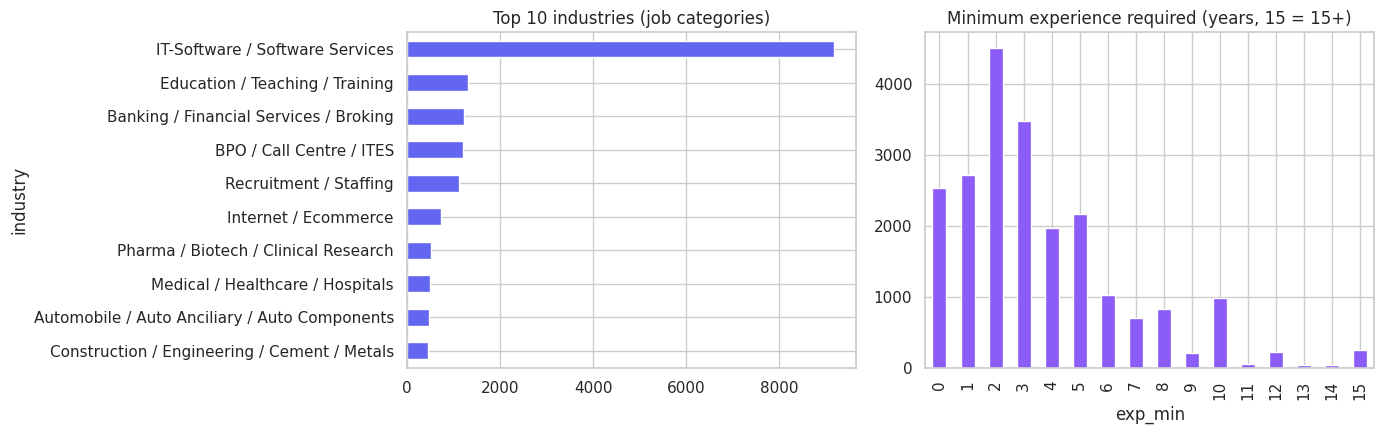

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
jobs.industry.value_counts().head(10).iloc[::-1].plot.barh(ax=ax[0], color='#6366F1'); ax[0].set_title('Top 10 industries (job categories)')
jobs.exp_min.dropna().clip(upper=15).astype(int).value_counts().sort_index().plot.bar(ax=ax[1], color='#8B5CF6'); ax[1].set_title('Minimum experience required (years, 15 = 15+)')
plt.tight_layout(); plt.show()

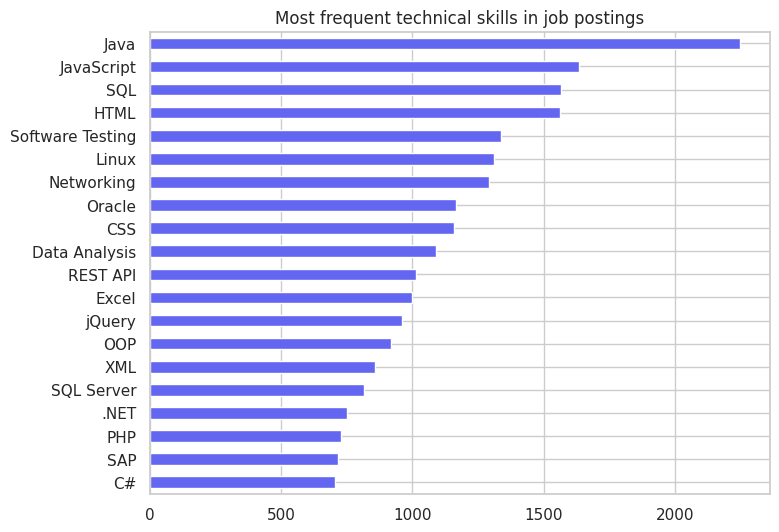

Postings with no detected skill: 11.7%


In [6]:
# Skill frequency (skills extracted from descriptions by the skill dictionary)
from src.skill_extractor import NON_TECH
valid = jobs[jobs.is_valid]
freq = Counter(s for l in valid.req_skills for s in l)
top = pd.Series({k: v for k, v in freq.items() if k not in NON_TECH}).sort_values(ascending=False).head(20)
top.iloc[::-1].plot.barh(figsize=(8, 6), color='#6366F1', title='Most frequent technical skills in job postings'); plt.show()
print('Postings with no detected skill:', f'{(valid.n_skills == 0).mean():.1%}')

In [7]:
res, path = load_resume_dataset()
if res is None:
    print('No resume dataset found in dataset/ or data/resumes/  ->  weak-label training on Naukri jobs will be used.')
else:
    print(path, res.shape); print(res.category.value_counts())

No resume dataset found in dataset/ or data/resumes/  ->  weak-label training on Naukri jobs will be used.


## 2. Text preprocessing

In [8]:
from src.text_processor import clean_text, tokenize, remove_stopwords, preprocess
sample = valid.job_description.iloc[5][:600]
print('RAW      :', sample[:300].replace('\xa0', ' '))
print('\nCLEANED  :', clean_text(sample)[:300])
toks = tokenize(sample); print('\nTOKENS   :', toks[:25])
nsw = remove_stopwords(toks); print('NO STOP  :', nsw[:25])
print('\nNORMALISED (light stemming):', preprocess(sample)[:300])

RAW      : Job Description   Send me Jobs like this We are currently hiring candidates willing to work on JD Edwards Worldsoft Developer Job Details: * Expertise in RPG programming. * Good Knowledge in ERP domain. * Knowledge in OMS/WMS will be an added advantage. * Excellent communication and interpersonal sk

CLEANED  : job description send me jobs like this we are currently hiring candidates willing to work on jd edwards worldsoft developer job details expertise in rpg programming good knowledge in erp domain knowledge in oms wms will be an added advantage excellent communication and interpersonal skills intereste

TOKENS   : ['job', 'description', 'send', 'me', 'jobs', 'like', 'this', 'we', 'are', 'currently', 'hiring', 'candidates', 'willing', 'to', 'work', 'on', 'jd', 'edwards', 'worldsoft', 'developer', 'job', 'details', 'expertise', 'in', 'rpg']
NO STOP  : ['send', 'jobs', 'like', 'currently', 'hiring', 'candidates', 'willing', 'jd', 'edwards', 'worldsoft', 'developer', 'detail

## 3. Model training
**Weak labels.** Each Naukri job title is mapped to one of the six project roles by ordered keyword rules (`src/classifier.py: TITLE_RULES`). Titles that match no rule are *excluded*, not forced into a class. The job *title field* and Naukri's own `Role:` metadata are never used as features.

naukri_weak_labels - No resume dataset was provided. Trained on Naukri job postings, labelled by job-title keyword rules for the six project roles (title field and Naukri 'Role' metadata excluded from the text). Labels are rule-derived, not human-annotated, and the model is applied to resumes (domain shift).

label
Software Developer           3115
Web Developer                 907
Data Analyst                  295
Cyber Security Analyst         82
Data Scientist                 49
Machine Learning Engineer      30
Name: count, dtype: int64


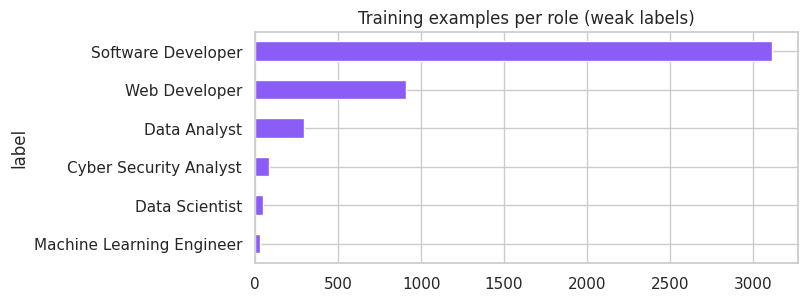


Classes below 50 examples (unreliable metrics): ['Data Scientist', 'Machine Learning Engineer']


In [9]:
from src.classifier import build_training_data, TITLE_RULES
texts, labels, info = build_training_data()
print(info['source'], '-', info['description']); print()
counts = labels.value_counts(); print(counts)
counts.iloc[::-1].plot.barh(figsize=(7, 3), color='#8B5CF6', title='Training examples per role (weak labels)'); plt.show()
print('\nClasses below 50 examples (unreliable metrics):', list(counts[counts < 50].index))

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
texts, labels = pd.Series(texts).reset_index(drop=True), pd.Series(labels).reset_index(drop=True)
enc = LabelEncoder().fit(labels); y = enc.transform(labels)
Xtr_t, Xte_t, ytr, yte = train_test_split(texts, y, test_size=0.2, stratify=y, random_state=42)   # stratified split
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9, max_features=40000, sublinear_tf=True)
Xtr, Xte = vec.fit_transform(Xtr_t), vec.transform(Xte_t)
print('train', Xtr.shape, 'test', Xte.shape)
models = {'Logistic Regression': LogisticRegression(max_iter=2000, C=10, class_weight='balanced'),
          'Linear SVM': LinearSVC(C=1.0, class_weight='balanced')}
skf = StratifiedKFold(5, shuffle=True, random_state=42)
cv = {n: cross_val_score(m, Xtr, ytr, cv=skf, scoring='f1_macro') for n, m in models.items()}
pd.DataFrame({n: {'CV macro-F1 mean': s.mean(), 'CV macro-F1 std': s.std()} for n, s in cv.items()}).T.round(3)

train (3582, 27718) test (896, 27718)


,CV macro-F1 mean,CV macro-F1 std
Logistic Regression,0.756,0.043
Linear SVM,0.757,0.032


## 4. Evaluation (held-out test set)

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
best = max(cv, key=lambda n: cv[n].mean()); model = models[best].fit(Xtr, ytr); pred = model.predict(Xte)
p, r, f, _ = precision_recall_fscore_support(yte, pred, average='macro', zero_division=0)
print(f'Selected model (by CV macro-F1): {best}')
print(f'Accuracy {accuracy_score(yte, pred):.3f} | macro Precision {p:.3f} | macro Recall {r:.3f} | macro F1 {f:.3f}\n')
print(classification_report(yte, pred, target_names=enc.classes_, zero_division=0))

Selected model (by CV macro-F1): Linear SVM
Accuracy 0.872 | macro Precision 0.761 | macro Recall 0.715 | macro F1 0.735

                           precision    recall  f1-score   support

   Cyber Security Analyst       0.93      0.81      0.87        16
             Data Analyst       0.81      0.88      0.85        59
           Data Scientist       0.75      0.60      0.67        10
Machine Learning Engineer       0.40      0.33      0.36         6
       Software Developer       0.91      0.92      0.92       623
            Web Developer       0.76      0.74      0.75       182

                 accuracy                           0.87       896
                macro avg       0.76      0.71      0.74       896
             weighted avg       0.87      0.87      0.87       896



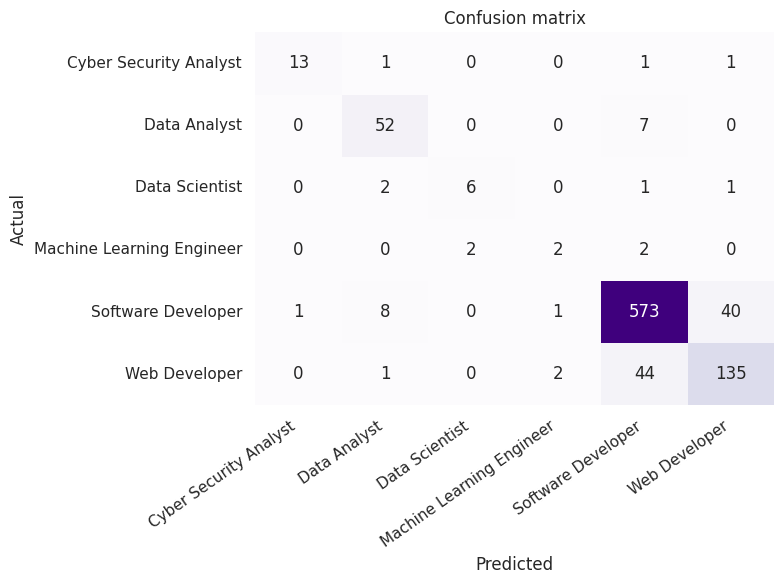

In [12]:
cm = confusion_matrix(yte, pred)
plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=enc.classes_, yticklabels=enc.classes_, cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix'); plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

**Reading these results honestly**
- Accuracy is dominated by *Software Developer* (the largest class); **macro** F1 is the fairer headline number.
- *Data Scientist* and *Machine Learning Engineer* have very few examples, so their test-set scores rest on 6-10 samples and can swing a lot.
- Labels come from title rules, not human annotation, and the model is later applied to resumes (a different text domain). Treat predictions as a hint, not ground truth.
- Metrics were *not* tuned on the test set: model choice used cross-validation on the training split only.

## 5. Matching experiment: Resume + Job Description -> compatibility score

In [13]:
from src.resume_parser import parse_resume
from src.job_analyzer import analyze_job
from src.matcher import match_resume_to_job, skill_score, text_similarity
from src.config import SCORE_WEIGHTS
resume = parse_resume(open('../samples/resumes/sample_data_scientist.txt').read())
job = analyze_job(open('../samples/job_descriptions/sample_data_scientist_jd.txt').read())
print('Resume skills :', resume['skills']); print('Job required  :', job['required_skills']); print('Job preferred :', job['preferred_skills'], '(inferred)')
print('Experience    : resume', resume['experience']['years'], 'yrs  vs job', job['experience'])

Resume skills : ['A/B Testing', 'AWS', 'Business Intelligence', 'Computer Vision', 'Data Analysis', 'Data Science', 'Deep Learning', 'Docker', 'Excel', 'GCP', 'Git', 'Machine Learning', 'NLP', 'NumPy', 'Pandas', 'Power BI', 'PyTorch', 'Python', 'R', 'REST API', 'SQL', 'Sales', 'Scikit-learn', 'Statistics', 'Tableau', 'TensorFlow']
Job required  : ['AWS', 'Azure', 'Data Analysis', 'Data Science', 'Deep Learning', 'Docker', 'Git', 'Kubernetes', 'Machine Learning', 'NLP', 'NumPy', 'Pandas', 'PyTorch', 'Python', 'SQL', 'Scikit-learn', 'Statistics', 'TensorFlow']
Job preferred : [] (inferred)
Experience    : resume 3.7 yrs  vs job {'min': 3.0, 'max': 6.0, 'source': 'extracted (text pattern)'}


In [14]:
# TF-IDF fitted on the real job corpus, so IDF weights are meaningful
from src.recommender import JobIndex
index = JobIndex(jobs)
res = match_resume_to_job(resume, job, index.vec)
print('Weights configured:', SCORE_WEIGHTS)
for k in ['overall', 'skill', 'text', 'experience', 'education']: print(f'{k:>10}: {res[k]}')
print('raw cosine:', res['text_raw_cosine']); print('matching:', res['matching_skills']); print('missing :', res['missing_skills'])

Weights configured: {'skills': 0.5, 'text': 0.25, 'experience': 0.15, 'education': 0.1}
   overall: 89.5
     skill: 88.9
      text: 80.2
experience: 100.0
 education: 100.0
raw cosine: 0.401
matching: ['AWS', 'Data Analysis', 'Data Science', 'Deep Learning', 'Docker', 'Git', 'Machine Learning', 'NLP', 'NumPy', 'Pandas', 'PyTorch', 'Python', 'SQL', 'Scikit-learn', 'Statistics', 'TensorFlow']
missing : ['Azure', 'Kubernetes']


In [15]:
from src.recommender import recommend_jobs
recs = recommend_jobs(resume, index, top_n=10)
recs[['job_title', 'company', 'location', 'match_score', 'skill_score', 'text_score']]

,job_title,company,location,match_score,skill_score,text_score
0,Analytics & Data Science,Startup - Entransys,Hyderabad,79.7,100.0,18.9
1,Executive MIS :: Sharp Sight Eye Hospitals :: Delhi,Sharp Sight Laser Centre Pvt Ltd,Delhi,78.3,100.0,13.2
2,Analytics Engineer Openings Based out in Bangalore,Target,Bengaluru,78.1,100.0,21.1
3,Analyst,CZ Insights,Bengaluru,77.5,100.0,10.2
4,Service Quality - Debt Mgt - Chennai,HDFC Bank Limited,Chennai,76.8,100.0,7.1
5,Very Very Urgent Requirement for Collateral Management role,ANRI SOLUTIONS HR SERVICES PVT LTD,Mumbai,73.9,100.0,5.9
6,Asst Manager - Data Analysis,HERITAGE FOODS LIMITED,Hyderabad,73.5,100.0,9.7
7,Senior BI Consultant,Brillio Technologies Pvt. Ltd,Bengaluru,73.3,100.0,16.3
8,MIS Executive,QUANTUM ASSET MANAGEMENT COMPANY PRIVATE LIMITED.,Mumbai,71.0,80.0,24.0
9,"Immediate Opening for MSBI Power BI Developer, 3+ Yrs, Bangalore",ASAP Info Systems Pvt Ltd,Bengaluru,70.3,80.0,21.0
